## Outline
This Notebook will look at the EDA aspect with deleting unnecessary rows and performing some kind of cleaning along the way.

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('..\\1. Data Cleaning\\zameen_cleaned_v2.csv',index_col=0)

In [6]:
df.head()

,Precise Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,D-12/2,House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,D-12/1,House,5.20,4,4.4,3,D-12,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,D-12/4,House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
3,D-12/1,House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
4,Bahria Enclave - Sector H,House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [7]:
df.shape

(6359, 39)

In [8]:
df.columns

Index(['Precise Location', 'Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)',
       'Bedroom(s)', 'Location', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'Main Location', 'Building',
       'IsPrimeLoc', 'SolarInstalled', 'WaterBore', 'CornerHouse',
       'luxury_type', 'Built in year', 'Parking Spaces', 'Floor',
       'Lobby in Building', 'Elevators', 'Service Elevators in Building',
       'Floor in Building', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Sauna', 'Jacuzzi',
       'Security Staff', 'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen'],
      dtype='object')

*Removing 'Location','Precise Location' as we will not be needing it*

- Main Location --> Location of the Flats and Houses
- Building --> Only for Flats

In [9]:
df.drop(columns=['Precise Location','Location'],inplace=True)

In [10]:
# Bringing 'Building to the 1st column'

In [11]:
cols = ['Main Location'] + [c for c in df.columns if c != 'Main Location']
df = df[cols]
cols = ['Building'] + [c for c in df.columns if c != 'Building']
df = df[cols]

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            6359 non-null   object 
 1   Main Location                       6359 non-null   object 
 2   Type                                6359 non-null   object 
 3   Price(Cr)                           6359 non-null   float64
 4   Bath(s)                             6359 non-null   object 
 5   Area(Marla)                         6359 non-null   float64
 6   Bedroom(s)                          6359 non-null   object 
 7   Description                         6359 non-null   object 
 8   Amenities: Main Features            5907 non-null   object 
 9   Amenities: Rooms                    5742 non-null   object 
 10  Amenities: Healthcare Recreational  4969 non-null   object 
 11  Amenities: Other Facilities         5557 non-nul

Will remove :<br> *'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Other Facilities'* <br>but keeping them for now for better decisions

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
# No of null values in each column
df.isnull().sum()

Building                                 0
Main Location                            0
Type                                     0
Price(Cr)                                0
Bath(s)                                  0
Area(Marla)                              0
Bedroom(s)                               0
Description                              0
Amenities: Main Features               452
Amenities: Rooms                       617
Amenities: Healthcare Recreational    1390
Amenities: Other Facilities            801
IsPrimeLoc                               0
SolarInstalled                           0
WaterBore                                0
CornerHouse                              0
luxury_type                              0
Built in year                         1161
Parking Spaces                         850
Floor                                 1810
Lobby in Building                     5113
Elevators                             5213
Service Elevators in Building         5265
Floor in Bu

## Type

In [16]:
df['Type'].value_counts()

Type
House         4524
Flat          1729
Farm House      89
Penthouse       14
Room             2
Name: count, dtype: int64

In [17]:
# Removing Type='Room' as it will create bias
df = df[~df['Type'].isin(['Room'])] 

In [18]:
sns.set_palette(["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"])

<Axes: xlabel='Type', ylabel='count'>

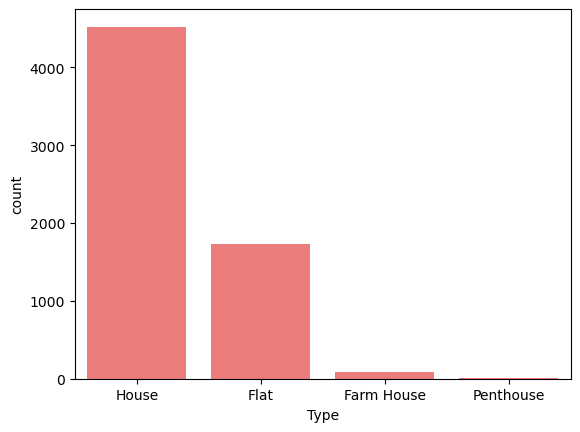

In [19]:
sns.countplot(x=df['Type'])

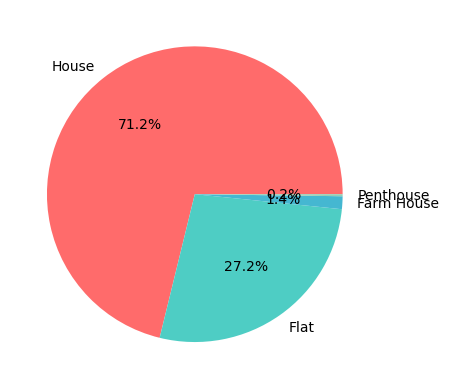

In [20]:
plt.pie(x=df['Type'].value_counts(),labels=df['Type'].value_counts().index,autopct='%1.1f%%');

### Observations
- In our Data, mostly data consists of House, then flats.
- Very few are PentHouse and Farm House

## Price(Cr)

In [21]:
df['Price(Cr)'].describe()

count     6356.000000
mean        20.567385
std        878.106557
min          0.220000
25%          2.200000
50%          4.100000
75%          9.355000
max      70000.000000
Name: Price(Cr), dtype: float64

<Axes: xlabel='Price(Cr)', ylabel='Density'>

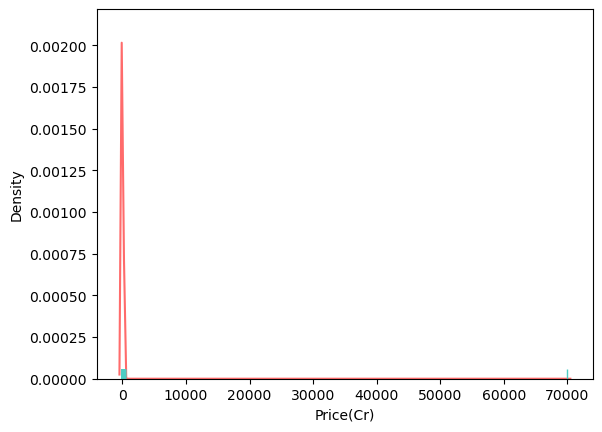

In [22]:
sns.kdeplot(df['Price(Cr)'])
sns.rugplot(df['Price(Cr)'])

In [23]:
df[df['Price(Cr)']==df['Price(Cr)'].max()]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
1207,Unknown,Faisal Town Phase 1,House,70000.0,6,14.0,6,14 Marla Home For Sale In F-18 Faisal Town Isl...,NaN,"Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...",...,2.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN


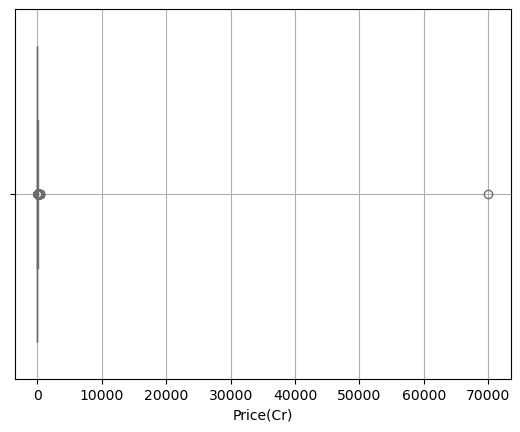

In [24]:
sns.boxplot(x=df['Price(Cr)'])
plt.grid();

In [25]:
# Removing the obvious outlier 
df = df[df['Price(Cr)']!=df['Price(Cr)'].max()]

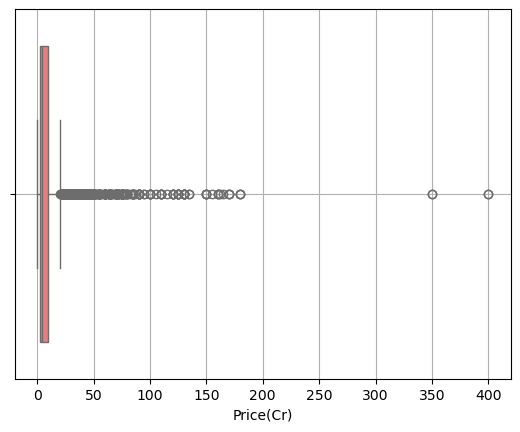

In [26]:
sns.boxplot(x=df['Price(Cr)'])
plt.grid();

### Descriptive Statistics
- No Null values
- Mean (20.356 Cr) is greater than Median (4.1 Cr)
- Standard Deviation is very high indicating high variability in data
### Visualiations
- Data is Right Skewed
- A lot of outliers are there.
- Majority of data exists below 2 Cr and few below 10 Cr

<Axes: xlabel='Price(Cr)', ylabel='Count'>

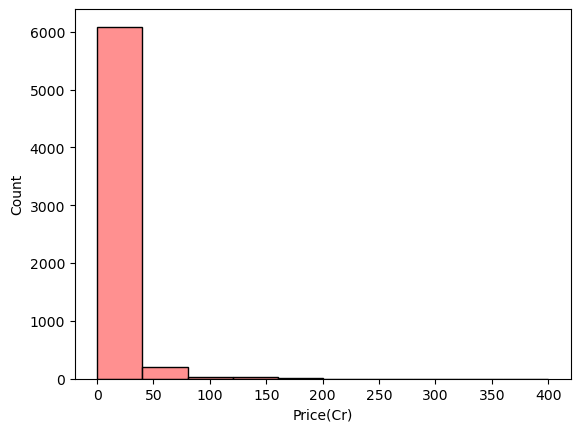

In [27]:
sns.histplot(df['Price(Cr)'],bins=10)

In [28]:
print('Skewness:', df['Price(Cr)'].skew())
print('Kurtosis:', df['Price(Cr)'].kurtosis())

Skewness: 7.860944190705231
Kurtosis: 108.00225967249915


- **Skewness:** 7.86 indicating positive skewness

- **Kurtosis:** 108 which is very high meaning that the tails are heavier indicating outliers(which could be seen using boxplot)

In [29]:
df['Price(Cr)'].quantile([0.01,0.1,0.5,0.9,0.99])

0.01     0.45
0.10     0.95
0.50     4.10
0.90    20.00
0.99    85.00
Name: Price(Cr), dtype: float64

<Axes: xlabel='Price(Cr)', ylabel='Proportion'>

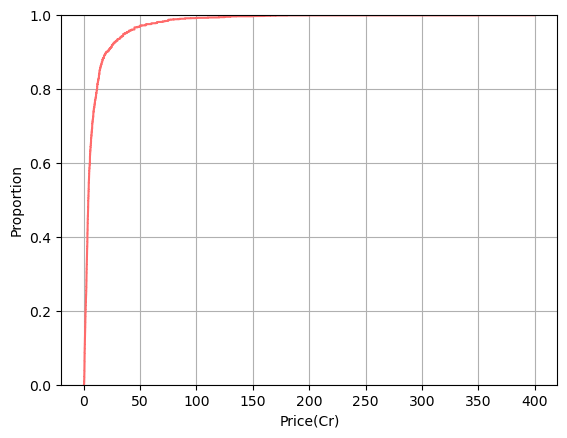

In [30]:
# ECDF Plot 
plt.grid()
sns.ecdfplot(df['Price(Cr)'])

- About 90% of data lies under 20 Cr.

In [31]:
q1,q3 = df['Price(Cr)'].quantile([0.25,0.75])
IQR = q3 - q1

lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

print(lower_bound,upper_bound)

-8.524999999999999 20.075


In [40]:
outliers = df[(df['Price(Cr)']<lower_bound) | (df['Price(Cr)'] > upper_bound)]

In [41]:
outliers['Price(Cr)'].describe()

count    631.000000
mean      49.881474
std       40.161189
min       20.500000
25%       27.000000
50%       36.500000
75%       55.000000
max      400.000000
Name: Price(Cr), dtype: float64

### Outliers Observations
- There are 631 outliers according to IQR
- The range for outliers is 49 Cr till 400 Cr

In [42]:
print('Skewness:', np.log1p(df['Price(Cr)']).skew())
print('Kurtosis:', np.log1p(df['Price(Cr)']).kurtosis())

Skewness: 0.8532596464497896
Kurtosis: 0.6664593276760438


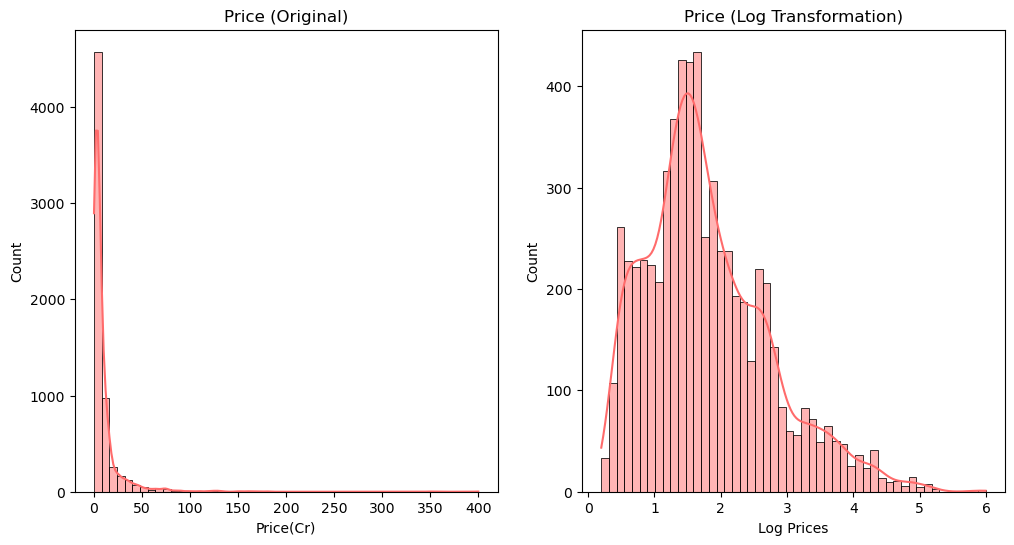

In [43]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

# Before Transformation
sns.histplot(df['Price(Cr)'],kde=True,bins=50,ax=axes[0])
axes[0].set_title('Price (Original)')

sns.histplot(np.log1p(df['Price(Cr)']),kde=True,bins=50,ax=axes[1])
axes[1].set_title('Price (Log Transformation)')
axes[1].set_xlabel('Log Prices');

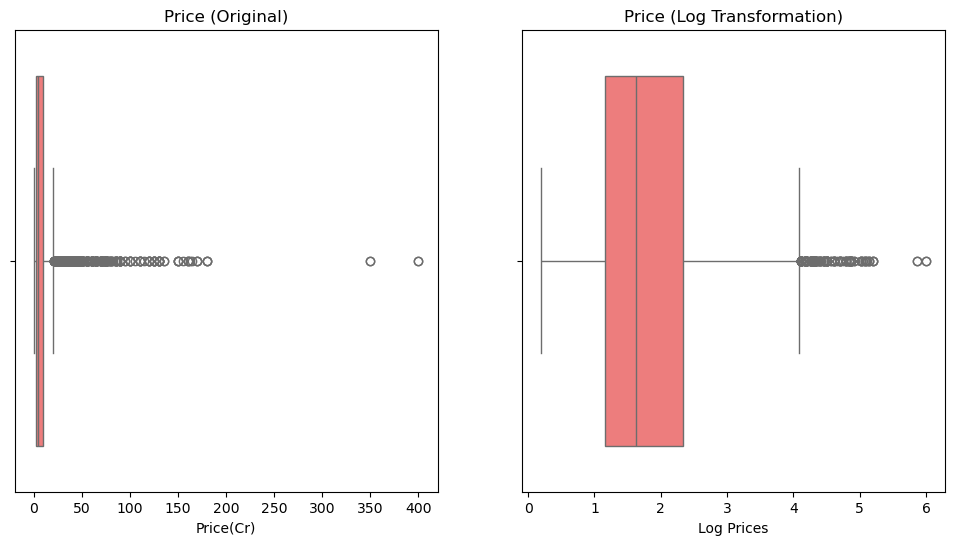

In [44]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

# Before Transformation
sns.boxplot(x=df['Price(Cr)'],ax=axes[0])
axes[0].set_title('Price (Original)')

sns.boxplot(x=np.log1p(df['Price(Cr)']),ax=axes[1])
axes[1].set_title('Price (Log Transformation)')
axes[1].set_xlabel('Log Prices');

**Log Transformation** looks helpful there

## Bath(s)

In [45]:
df['Bath(s)'].isnull().sum()

np.int64(0)

In [46]:
df['Bath(s)'].value_counts()

Bath(s)
6     2028
5      879
2      818
4      733
3      629
7      470
1      462
-      331
10       3
9        1
8        1
Name: count, dtype: int64

*There is a category '-' need to fix it*

In [47]:
# Need to fill the category '-', filling from Bathrooms
df.loc[df['Bath(s)']=='-','Bath(s)'] = df['Bathrooms'].astype(str)

In [48]:
df['Bath(s)'] = df['Bath(s)'].astype(float)

In [49]:
df['Bath(s)'].value_counts()

Bath(s)
6.0     2054
5.0      903
2.0      836
4.0      756
3.0      652
7.0      503
1.0      472
8.0       25
9.0       13
10.0      13
12.0       5
11.0       5
14.0       2
16.0       1
13.0       1
Name: count, dtype: int64

<Axes: xlabel='Bath(s)', ylabel='count'>

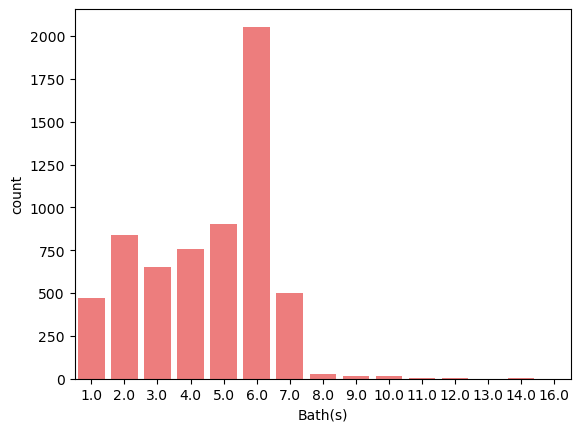

In [50]:
sns.barplot(df['Bath(s)'].value_counts())

## Bedroom(s)

In [51]:
df['Bedroom(s)'].isnull().sum()

np.int64(0)

In [52]:
df['Bedroom(s)'].value_counts()

Bedroom(s)
5     1356
4     1000
2      942
6      923
3      762
1      389
7      339
-      303
8      154
9      100
10      67
11      20
Name: count, dtype: int64

In [53]:
# Need to fill '-' from Bedrooms
df.loc[df['Bedroom(s)']=='-','Bedroom(s)'] = df['Bedrooms'].astype(str)

In [54]:
df['Bedroom(s)'] = df['Bedroom(s)'].astype(float)

In [55]:
df['Bedroom(s)'].value_counts()

Bedroom(s)
5.0     1377
4.0     1021
2.0      960
6.0      936
3.0      792
1.0      447
7.0      344
8.0      158
9.0      103
10.0      68
11.0      22
0.0        5
14.0       3
Name: count, dtype: int64

In [65]:
# Zero Bedrooms doesnot make sense, setting it to Nan
df.loc[df['Bedroom(s)']==0,'Bedroom(s)'] = np.nan 

<Axes: xlabel='Bedroom(s)', ylabel='count'>

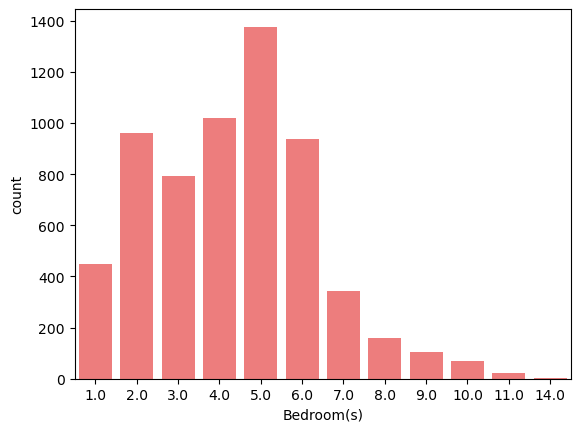

In [66]:
sns.barplot(df['Bedroom(s)'].value_counts())

### Observations from Bath(s) & Bedroom(s)
- In Bath(s), the most frequent no. of Bathrooms is 6.
- In Bedroom(s), the most frequent no. of Bedrooms is 5.
- In both columns, after 7 the number of Bathroom and Bedroom starts to decrease.

## Area(Marla)

In [67]:
df['Area(Marla)'].isnull().sum()

np.int64(0)

In [68]:
df['Area(Marla)'].describe()

count    6355.000000
mean       16.436900
std        73.995866
min         0.700000
25%         5.000000
50%         8.000000
75%        14.900000
max      3000.000000
Name: Area(Marla), dtype: float64

<Axes: xlabel='Area(Marla)', ylabel='Count'>

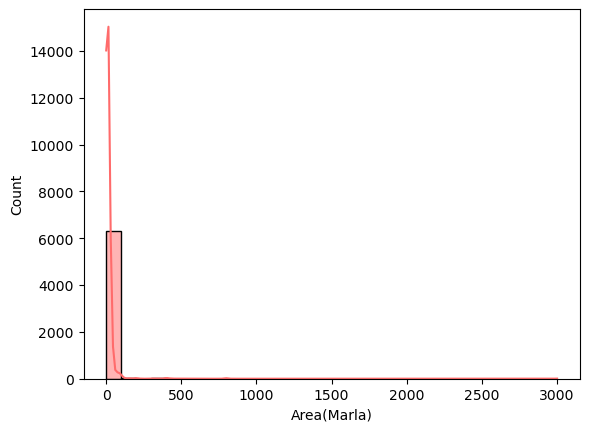

In [69]:
sns.histplot(df['Area(Marla)'],kde=True,bins=30)

<Axes: xlabel='Area(Marla)'>

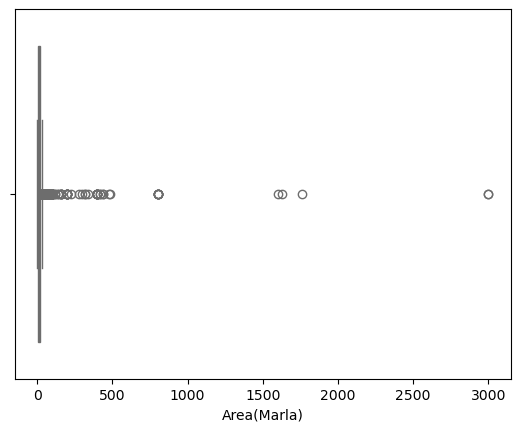

In [70]:
sns.boxplot(x=df['Area(Marla)'])

### Descriptive Statistics
- Mean is 16.43 Marla
- Median is 8 Marla
- Mean is larger than Median indicating Outliers
- Standard Deviation being higher also indicates high variability.
- Data is highly right skewed

In [71]:
df['Area(Marla)'].quantile([0.01,0.1,0.5,0.9,0.95,0.99])

0.01      1.7
0.10      3.8
0.50      8.0
0.90     20.0
0.95     40.0
0.99    100.0
Name: Area(Marla), dtype: float64

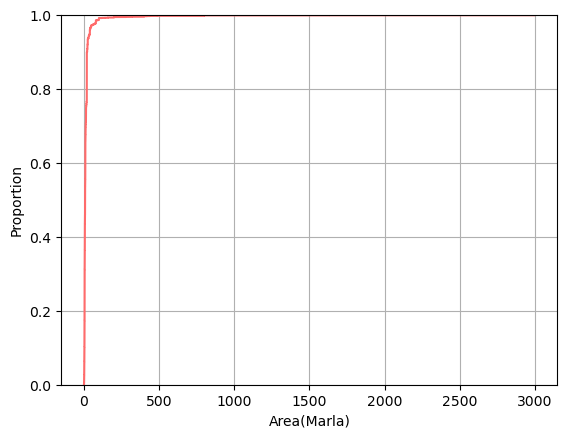

In [72]:
plt.grid()
sns.ecdfplot(df['Area(Marla)']);

### Quantile Observations
- 10% of Data lies below 1.7 Marla
- 50% of Data lies below 8 Marla
- 95% of Data lies below 20 Marla

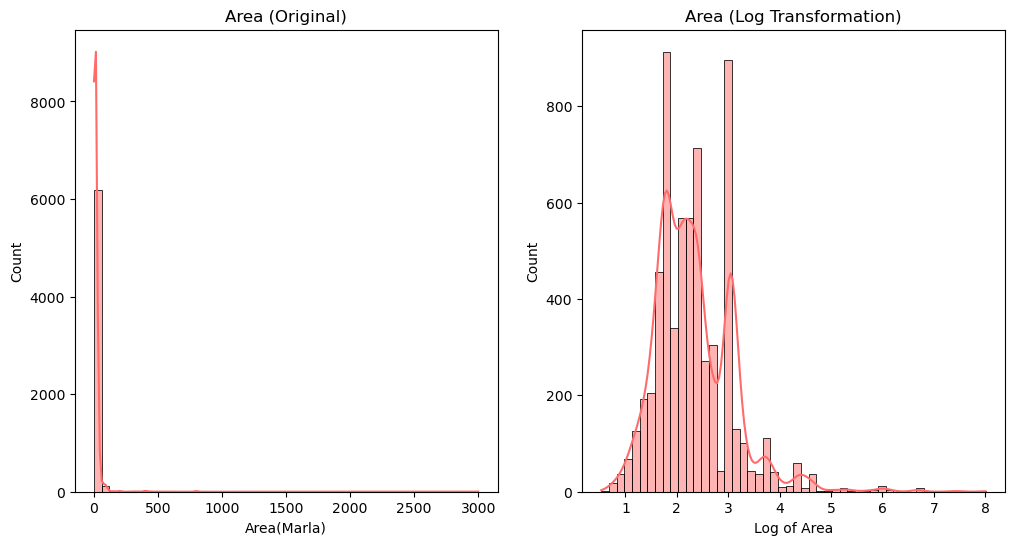

In [73]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

sns.histplot(df['Area(Marla)'],kde=True,bins=50,ax=axes[0])
axes[0].set_title('Area (Original)')

sns.histplot(np.log1p(df['Area(Marla)']),kde=True,bins=50,ax=axes[1])
axes[1].set_title('Area (Log Transformation)')
axes[1].set_xlabel('Log of Area');


## Main Location

In [74]:
df['Main Location'].isnull().sum()

np.int64(0)

In [75]:
df['Main Location'].value_counts()

Main Location
DHA Phase 2                       562
G-13                              331
Bahria Enclave                    308
B-17                              279
Bani Gala                         240
                                 ... 
Phulgran                            1
Thalian                             1
Murree Road                         1
Engineers Co-operative Housing      1
Alipur Farash                       1
Name: count, Length: 143, dtype: int64

In [76]:
df['Main Location'].value_counts(normalize=True).cumsum().head(50)

Main Location
DHA Phase 2              0.088434
G-13                     0.140519
Bahria Enclave           0.188985
B-17                     0.232887
Bani Gala                0.270653
MPCHS - Multi Gardens    0.307946
D-12                     0.344453
Top City 1               0.377970
Gulberg Greens           0.411015
F-8                      0.441070
Faisal Town Phase 1      0.467663
F-11                     0.494256
G-11                     0.518804
F-10                     0.542250
DHA Phase 5              0.564437
E-11                     0.586467
F-7                      0.605350
Soan Garden              0.623131
Bahria Town              0.640598
F-6                      0.657592
G-9                      0.673171
I-8                      0.687805
DHA Valley               0.701023
G-15                     0.712825
Mumtaz City              0.723839
G-10                     0.734540
DHA Phase 1              0.744925
Gulberg Residencia       0.755311
D-17                     0.765539


In [77]:
location_counts = df['Main Location'].value_counts()

frequency_bins = {
    'Very high (>200) ':int((location_counts>200).sum()),
    'High (100-200) ' : int(((location_counts>=100) & (location_counts<=200) ).sum()),
    'Moderate (99-40)': int(((location_counts>=40)&(location_counts<=99)).sum()),
    'Low (39-15)': int(((location_counts>=15)&(location_counts<=39)).sum()),
    'Very Low(14-5)': int(((location_counts>=5)&(location_counts<=14)).sum()),
    "Rare (<5)":int((location_counts<5).sum())
}

frequency_bins

{'Very high (>200) ': 9,
 'High (100-200) ': 11,
 'Moderate (99-40)': 23,
 'Low (39-15)': 22,
 'Very Low(14-5)': 25,
 'Rare (<5)': 53}

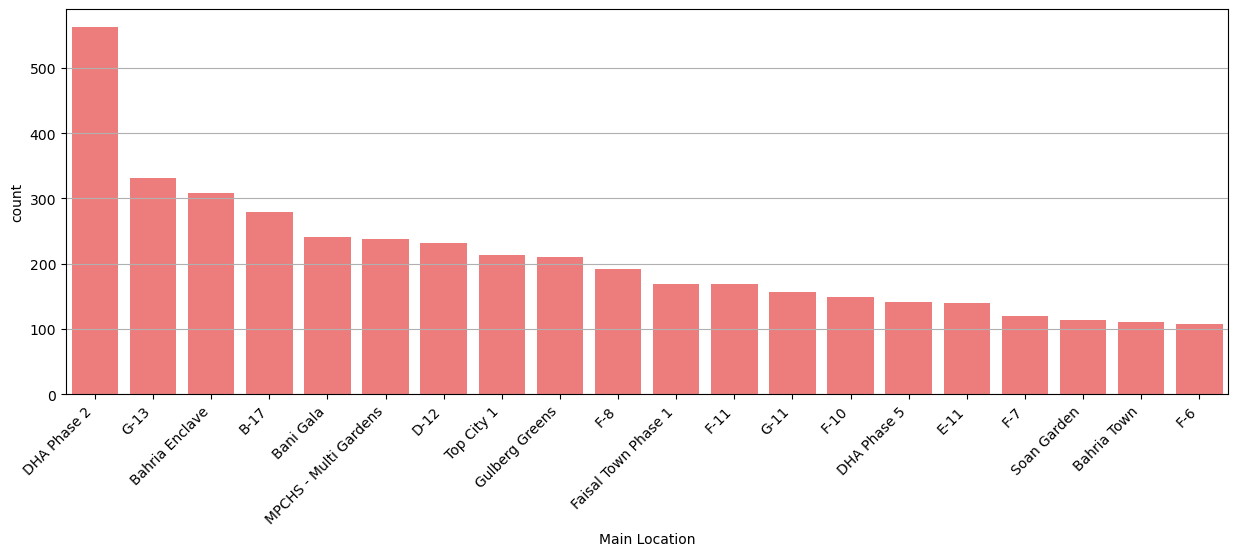

In [78]:
plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(df['Main Location'].str.strip().value_counts().head(20))
plt.xticks(rotation=45,ha='right')
plt.show()

### Observations
- DHA Phase 2 contains 9% of the Data.
- Total 111 different locations
- Top 12 locations contains 50% of data, rest contains the rest 50% :
  - Very High(>200): Only 9 location has more than 500 listings
  - High(100 - 200): 11 locations have listings between 100 and 500
  - Moderate(99-40): 23 locations have listings between 40 and 99
  - Low(39-15): 22 locations have listings between 15 and 39
  - Very Low(14-5): 25 locations have less than 15 listings
  - Rare(<5): 53 locations have less than 15 listings

## Building

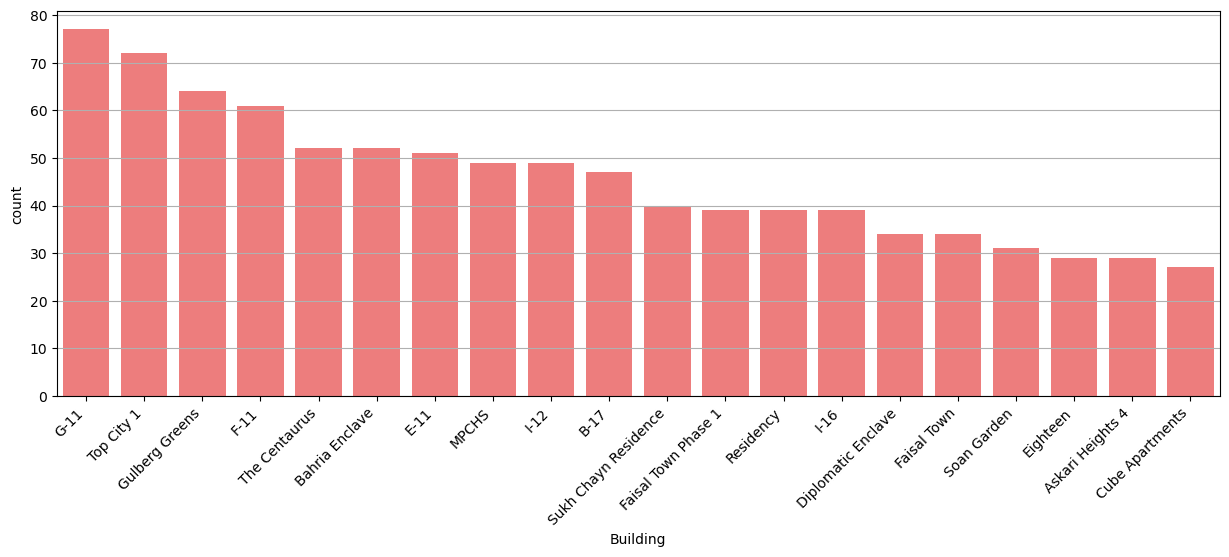

In [81]:
building_only = df[df['Building']!='Unknown']

plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(building_only['Building'].str.strip().value_counts().head(20))
plt.xticks(rotation=45,ha='right')
plt.show()

In [83]:
building_only['Building'].value_counts(normalize=True).cumsum().head(50)

Building
G-11                            0.044177
Top City 1                      0.085485
Gulberg Greens                  0.122203
F-11                            0.157200
The Centaurus                   0.187034
Bahria Enclave                  0.216867
E-11                            0.246127
MPCHS                           0.274240
I-12                            0.302352
B-17                            0.329317
Sukh Chayn Residence            0.352266
Faisal Town Phase 1             0.374641
Residency                       0.397017
I-16                            0.419392
Diplomatic Enclave              0.438898
Faisal Town                     0.458405
Soan Garden                     0.476190
Eighteen                        0.492828
Askari Heights 4                0.509466
Cube Apartments                 0.524957
Zarkon Heights                  0.539874
Al-Ghurair Giga                 0.553643
D-17                            0.567413
DHA Phase 2                     0.580608
Goldcre

## IsPrimeLoc, SolarInstalled, WaterBore, CornerHouse

In [84]:
df[['IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse']].isnull().sum()

IsPrimeLoc        0
SolarInstalled    0
WaterBore         0
CornerHouse       0
dtype: int64

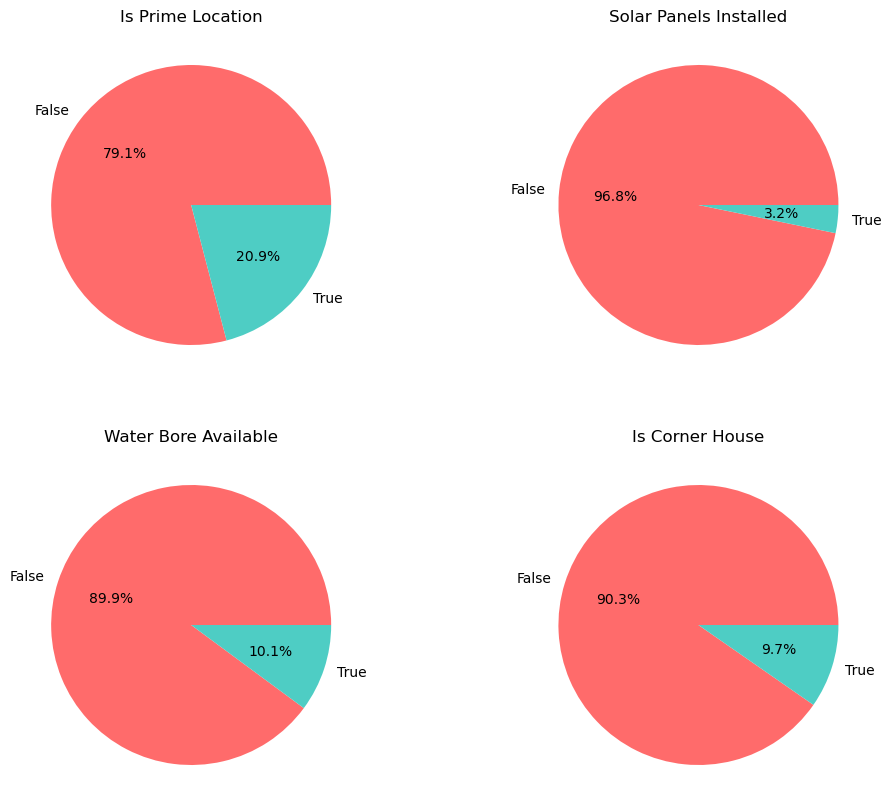

In [85]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

axes[0,0].pie(df['IsPrimeLoc'].value_counts(),autopct='%1.1f%%',labels=df['IsPrimeLoc'].value_counts().index)
axes[0,0].set_title('Is Prime Location')

axes[0,1].pie(df['SolarInstalled'].value_counts(),autopct='%1.1f%%',labels=df['SolarInstalled'].value_counts().index)
axes[0,1].set_title('Solar Panels Installed')

axes[1,0].pie(df['WaterBore'].value_counts(),autopct='%1.1f%%',labels=df['WaterBore'].value_counts().index)
axes[1,0].set_title('Water Bore Available')

axes[1,1].pie(df['CornerHouse'].value_counts(),autopct='%1.1f%%',labels=df['CornerHouse'].value_counts().index)
axes[1,1].set_title('Is Corner House')

plt.show()

In [86]:
df.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Swimming Pool', 'Sauna', 'Jacuzzi', 'Security Staff',
       'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen'],
      dtype='str')

## Luxury Score
0 --> Luxurious <br>
1 --> Budget

<Axes: xlabel='luxury_type', ylabel='count'>

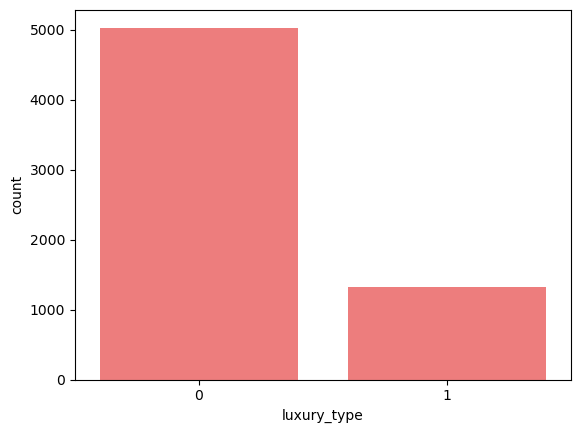

In [88]:
sns.barplot(df['luxury_type'].value_counts())

In [89]:
set(df[df['luxury_type']==0]['Amenities: Main Features'].dropna().sample(10).str.split(', ').sum())

{'Built in year',
 'Built in year: 2015',
 'Built in year: 2020',
 'Built in year: 2024',
 'Built in year: 2025',
 'Central Air Conditioning',
 'Central Heating',
 'Double Glazed Windows',
 'Electricity Backup',
 'Flooring',
 'Floors: 1',
 'Floors: 2',
 'Floors: 3',
 'Furnished',
 'Other Main Features',
 'Parking Spaces',
 'Parking Spaces: 1',
 'Parking Spaces: 2',
 'Parking Spaces: 4',
 'Waste Disposal'}

In [90]:
set(df[df['luxury_type']==1]['Amenities: Main Features'].dropna().sample(5).str.split(', ').sum())

{'Built in year: 2022',
 'Built in year: 2023',
 'Built in year: 2025',
 'Double Glazed Windows',
 'Electricity Backup',
 'Elevators: 2',
 'Floor: 1',
 'Floor: 8',
 'Flooring',
 'Floors in Building: 5',
 'Floors in Building: 9',
 'Floors: 2.5',
 'Furnished',
 'Lobby in Building',
 'Parking Spaces',
 'Parking Spaces: 1',
 'Parking Spaces: 2',
 'Waste Disposal'}

## Built in Year

In [91]:
df['Built in year'].value_counts().sort_index()

Built in year
0.0           2
1.0         393
2.0          32
3.0          10
4.0           8
           ... 
2250.0        1
20000.0       1
20001.0       1
20223.0       4
122024.0      1
Name: count, Length: 79, dtype: int64

In [92]:
df[df['Built in year']==0.0]['Description']

3363    On a quest to find something remarkable in Isl...
6200    Ideally Located Luxury Apartment Building Banu...
Name: Description, dtype: str

### Observations
- Very misleading values.
- Many values are not even Years, they represent the number in how many years the house was built.

## Parking Spaces

In [93]:
df['Parking Spaces'].value_counts()

Parking Spaces
1.0       2843
2.0       1224
3.0        645
4.0        348
5.0        140
6.0         90
7.0         49
8.0         46
10.0        44
20.0        13
15.0         9
70.0         6
9.0          6
250.0        5
40.0         5
12.0         5
11.0         4
400.0        4
100.0        3
50.0         3
25.0         3
35.0         2
21.0         2
32.0         2
36.0         1
160.0        1
1000.0       1
96.0         1
500.0        1
2000.0       1
4000.0       1
Name: count, dtype: int64

In [94]:
df[df['Parking Spaces']>10]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
193,Unknown,G-13,House,10.75,6.0,20.0,6.0,"House for Sale Size, (50x90)1 Kanal Soled Coun...","Built in year: 1990, Parking Spaces: 20, Doubl...","Bedrooms: 4, Bathrooms: 4, Servant Quarters, D...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
325,Unknown,F-8,House,65.00,6.0,120.0,7.0,F-8/3 Luxurious House Available for Sale An ex...,"Built in year: 2019, Parking Spaces: 15, Doubl...","Bedrooms: 9, Bathrooms: 9, Servant Quarters: 3...",...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
410,Unknown,F-6,House,150.00,6.0,84.0,10.0,F -6 Corner House For Sale Old House Topclass ...,"Built in year: 2000, Parking Spaces: 20, Doubl...","Bedrooms: 10, Bathrooms: 10, Servant Quarters:...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
436,Unknown,Korang Town,House,3.55,6.0,9.0,6.0,8 Marla 3 Side Open House For Sale In Korang T...,"Built in year: 2024, Parking Spaces: 100, Doub...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 1...",...,2.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN
479,Bani Gala,Bani Gala,Flat,1.10,1.0,3.8,1.0,"Robina's Luxury Residences, Islamabad. Stunnin...","Built in year: 2018, Parking Spaces: 70, Lobby...","Bedrooms: 1, Bathrooms: 1, Drawing Room, Dinin...",...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5815,Goldcrest Highlife,DHA Phase 2,Flat,0.82,2.0,3.9,2.0,2 Bed Apartment For Sale In Gold Crest Highlif...,"Built in year: 2027, Parking Spaces: 2000, Lob...","Bedrooms: 2, Bathrooms, Servant Quarters: 1, D...",...,0.0,2.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN
5816,Goldcrest Views,DHA Phase 2,Flat,2.69,3.0,6.7,3.0,3 Bed Luxury Apartment for sale in Goldcrest V...,"Built in year: 2025, Parking Spaces: 4000, Lob...","Bedrooms: 3, Bathrooms: 3, Drawing Room, Dinin...",...,1.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN
6256,F-8,F-8,Flat,5.50,1.0,5.3,1.0,Your Property Requirement Just One Call Away! ...,"Built in year: 2021, Parking Spaces: 400, Lobb...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...",...,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN
6258,The Centaurus,F-8,Flat,4.10,1.0,2.9,1.0,Your Property Requirement Just One Call Away! ...,"Built in year: 2020, Parking Spaces: 250, Lobb...","Bedrooms: 1, Bathrooms: 2, Drawing Room, Dinin...",...,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [95]:
df[df['Parking Spaces']==1000]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
3231,Unknown,G-10,House,7.5,6.0,6.7,7.0,"Elegant,Modern, Stylish Triple Storey 3050 Hou...","Built in year: 2025, Parking Spaces: 1000, Dou...","Bedrooms: 7, Bathrooms: 9, Drawing Room, Dinin...",...,4.0,2.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN


### Observations
- Contains many outliers
- There is a crazy outlier having 1000 parking spaces.

## Floor

In [98]:
# Extracting Floor information through Description --> naming it 'Storey Unit'

In [99]:
import pandas as pd
import re

# Creating a sample 'temp' dataframe based on your edge cases
data = {'description': [
    'Beautiful 2 story house in Gulberg',
    'first floor available for rent',
    '1st Floor with nice view',
    'two point five story building',
    '1 unite for sale immediately',
    'single storey farm house',
    'double story with servant quarter',
    'random text with no storey info'
]}
temp = pd.DataFrame(data)

# 1. Define the Regex Pattern
# (?i) makes it case-insensitive.
# It looks for digits, words (one, two), ordinals (1st, first), or multiples (single, double)
# It also includes an optional check for decimals like " point five" or ".5"
# Then it looks for the keywords: storey, story, unit, unite, floor (with optional 's')
regex_pattern = r'(?i)\b((?:1|2|3|4|5|1st|2nd|3rd|one|two|three|first|second|third|single|double|triple)(?:\s+point\s+five|\.5)?)\s*-?\s*(?:storey|story|stories|unit|unite|floor)s?\b'

# 2. Extract the match into a temporary column
# We use .str.lower() and .str.strip() to normalize the text for easier mapping
temp['raw_extracted'] = temp['description'].str.extract(regex_pattern)[0].str.lower().str.strip()

# 3. Create a dictionary to map the messy text to clean floats/integers
storey_mapping = {
    '1': 1.0, '1st': 1.0, 'one': 1.0, 'first': 1.0, 'single': 1.0,
    '2': 2.0, '2nd': 2.0, 'two': 2.0, 'second': 2.0, 'double': 2.0,
    '3': 3.0, '3rd': 3.0, 'three': 3.0, 'third': 3.0, 'triple': 3.0,
    '2.5': 2.5, 'two point five': 2.5, '2.5': 2.5
}

# 4. Map the values to a final clean column and drop the temporary one
temp['storey_unit_clean'] = temp['raw_extracted'].map(storey_mapping)
temp = temp.drop(columns=['raw_extracted'])

(temp)

,description,storey_unit_clean
0,Beautiful 2 story house in Gulberg,2.0
1,first floor available for rent,1.0
2,1st Floor with nice view,1.0
3,two point five story building,2.5
4,1 unite for sale immediately,1.0
5,single storey farm house,1.0
6,double story with servant quarter,2.0
7,random text with no storey info,NaN


In [100]:
df['raw_extracted'] = df['Description'].str.extract(regex_pattern)[0].str.lower().str.strip()
df['Storey Unit'] = df['raw_extracted'].map(storey_mapping)
df.drop(columns=['raw_extracted'],inplace=True)

In [101]:
df['Storey Unit'].fillna(0).value_counts()

Storey Unit
0.0    4483
2.0    1178
1.0     391
3.0     289
2.5      14
Name: count, dtype: int64

In [106]:
# Total 4483 Null values
df['Storey Unit'].isnull().sum()

np.int64(4483)

In [107]:
df[df['Floor']>2].index

Index([  18,   33,   36,   46,   50,   62,   67,   69,   71,   87,
       ...
       6434, 6442, 6444, 6453, 6457, 6468, 6471, 6473, 6474, 6475],
      dtype='int64', length=1013)

In [110]:
df.loc[36].Floor

np.float64(8.0)

In [111]:
df[df['Floor']==0].index

Index([3858], dtype='int64')

In [112]:
df.loc[df[df['Floor']==0].index,'Floor'] =  df.loc[df[df['Floor']==0].index,'Storey Unit'].fillna(0)

In [113]:
df.loc[df[df['Floor']>2].index,'Storey Unit'].value_counts()

Storey Unit
3.0    134
2.0     74
1.0     50
2.5      5
Name: count, dtype: int64

In [114]:
df['Floor'].value_counts()

Floor
2.0      2577
1.0       953
3.0       567
4.0       109
5.0        88
6.0        52
7.0        44
8.0        35
10.0       25
9.0        20
11.0       11
12.0        8
13.0        8
2.5         7
20.0        5
17.0        4
1.5         4
22.0        4
24.0        3
18.0        3
14.0        3
15.0        3
26.0        2
21.0        2
40.0        2
16.0        2
37.0        1
32.0        1
19.0        1
0.0         1
41.0        1
123.0       1
34.0        1
Name: count, dtype: int64

<Axes: xlabel='Floor', ylabel='count'>

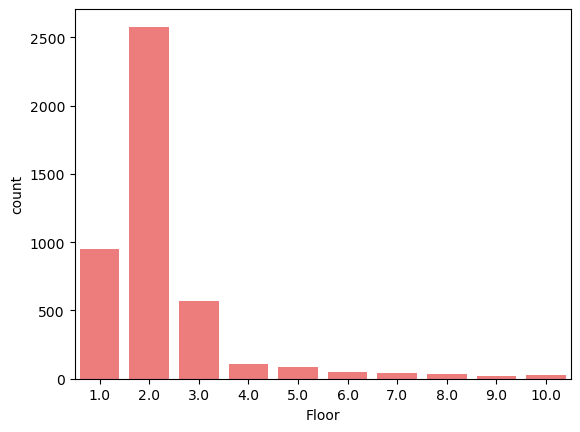

In [115]:
sns.barplot(df['Floor'].value_counts().head(10))

In [116]:
df[df['Floor']==0]['Description']

3858    House For Sale D-12 Islamabad Best Location Be...
Name: Description, dtype: str

In [117]:
df[df['Floor']>4]['Type'].value_counts()

Type
Flat     319
House     11
Name: count, dtype: int64

In [118]:
df[(df['Floor']>4)&(df['Type']=='House')]['Floor']

567     40.0
1517    13.0
3145    11.0
3989    40.0
4185     9.0
4208    41.0
4282    22.0
4958     6.0
5428    34.0
5872    15.0
6260    26.0
Name: Floor, dtype: float64

In [127]:
df[(df['Floor']>4)&(df['Type']=='House')]['Storey Unit']

1517    NaN
3145    2.0
3989    NaN
4185    NaN
4208    2.0
4282    NaN
4958    NaN
5428    NaN
5872    NaN
6260    NaN
Name: Storey Unit, dtype: float64

In [135]:
df.loc[6260]['Description']

"Your Property Requirement Just One Call Away! Hurry up hottest property This Is a Golden Chance To Book In Such A Luxury Project Which Has All Amenities. Finishing Work Is Started 1 Year Completion 3 Years Installments better than Centaurus And is in the Blue Area. Four-side corner Plot Every Flat Has Life Time Open View. It's Block Buster For Blue Area. Secure N Safe Investment For High Luxury Living N Best Rental This Perfect Investment shopping Mall Cooperate Office Hotel Save Mart Gym Spa Swimming Pool Call Us For More Details."

In [123]:
# 909 is a 'Flat' but its rest of features are given as 'House' --> removing it
df.drop(index=567,inplace=True)

In [136]:
df.drop(index=3989,inplace=True)

In [137]:
# Changing the values for 'Floor'>4 for Houses
df.loc[1517,'Floor'] = 2
df.loc[5428,'Floor'] = 2
df.loc[5872,'Floor'] = 1.5

## Lobby in Building, Service in Elevators, Elevators

In [138]:
df['Lobby in Building'].value_counts()

Lobby in Building
1.0    1245
Name: count, dtype: int64

In [139]:
df['Service Elevators in Building'].value_counts()

Service Elevators in Building
1.0    1093
Name: count, dtype: int64

In [140]:
df['Elevators'].value_counts()

Elevators
1.0     559
2.0     242
4.0     134
3.0      79
6.0      36
5.0      33
8.0      20
16.0     15
10.0      6
7.0       5
15.0      3
9.0       3
11.0      3
14.0      3
0.0       1
20.0      1
18.0      1
12.0      1
Name: count, dtype: int64

In [141]:
df[df['Elevators']>8]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
297,Bahria Enclave,Bahria Town,Flat,1.55,3.0,7.5,3.0,"The Galleria Mall, Civic Zone, Sector H Brand ...","Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Drawing Room, Dinin...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
299,Bahria Enclave,Bahria Town,Flat,1.50,3.0,7.5,3.0,A beautiful 1695 sq. ft apartment is available...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters, D...",...,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
692,Karakoram Diplomatic Enclave,Karakoram Diplomatic Enclave,Flat,13.50,4.0,11.8,3.0,Karakoram 3 bed rooms apartment with covered a...,"Built in year: 2018, Parking Spaces: 01, Lobby...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 0...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
1144,F-10,F-10,Flat,7.99,2.0,13.8,2.0,*The Garden Residence Luxury Apartments for Sa...,"Built in year: 2025, Parking Spaces: 3, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
1187,DHA Phase 1,DHA Phase 1,Flat,0.50,1.0,2.9,6.0,Studio Apartment For Sale on Installments. In ...,"Built in year: 2028, Parking Spaces: 1, Lobby ...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...",...,1.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN
1211,The Royal Mall and Residency,Bahria Enclave,Flat,1.60,2.0,5.6,2.0,Discover modern living in the heart of Bahria ...,"Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...",...,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
1258,Gulberg Arena Mall,Gulberg Greens,Flat,2.10,3.0,8.3,2.0,Gulberg areena two bed furnished r non furnish...,"Built in year: 2024, Parking Spaces: 4, Lobby ...","Bedrooms: 4, Bathrooms: 2, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
1334,The Royal Mall and Residency,Bahria Enclave,Flat,1.30,1.0,4.2,1.0,Beautifully designed 1 Bedroom Apartment avail...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 1, Bathrooms: 1, Servant Quarters: 1...",...,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN
1522,Bahria Enclave,Bahria Town,Flat,1.35,3.0,7.5,3.0,3 Bedroom Apartments for Sale Gold Category Pr...,"Built in year: 2024, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Kitchens: 1, Lounge...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1523,Bahria Enclave,Bahria Town,Flat,1.17,2.0,6.1,2.0,Brand new corner category 2-bedroom apartment ...,"Built in year: 2025, Parking Spaces: 2, Lobby ...","Bedrooms: 2, Bathrooms: 2, Kitchens: 1, Lounge...",...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN


## Servant Quarters

In [142]:
df['Servant Quarters'].isnull().sum() / df.shape[0]

np.float64(0.2664882732567291)

In [143]:
df['Servant Quarters'].value_counts().cumsum() / df['Servant Quarters'].dropna().shape[0]

Servant Quarters
 1.0     0.647425
 2.0     0.836695
 0.0     0.974893
 3.0     0.992060
 4.0     0.996996
 6.0     0.997639
 8.0     0.998283
 12.0    0.998712
 5.0     0.999142
-1.0     0.999356
 11.0    0.999571
 20.0    0.999785
 7.0     1.000000
Name: count, dtype: float64

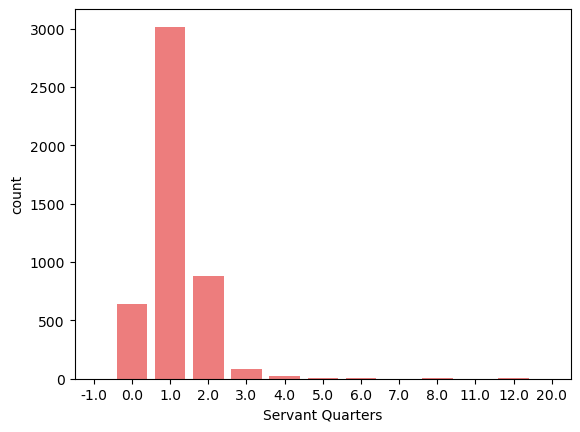

In [144]:
sns.barplot(df['Servant Quarters'].value_counts());

In [145]:
df[df['Servant Quarters']>4]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
52,Unknown,G-8,House,4.5000,4.0,5.6,4.0,25*50 Cda Transfer Back Open Good Location Hou...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 6...",...,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
203,Unknown,DHA Phase 2,House,15.0000,6.0,20.0,5.0,"1 Kanal Modern House for Sale DHA Phase 2, Isl...","Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
204,Unknown,DHA Phase 2,House,11.8000,7.0,20.0,6.0,Property Features: 1 Kanal (500 Sq. Yards) Dou...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...",...,2.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,2.0
803,Unknown,B-17,House,2.0500,4.0,5.0,4.0,Fasial Margalla City House. For sale 5 marla d...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,NaN,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN
1163,Unknown,Faisal Town Phase 1,House,3.5000,6.0,8.0,5.0,8 MARLA LUXURY DOUBLE STORY HOUSE FOR SALE IN ...,"Built in year: 1, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 6...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,2.0
1607,DHA Phase 1,DHA Phase 1,Flat,0.9064,1.0,1.8,1.0,"LUXURY STUDIO APARTMENT FOR SALE DHA PHASE 1 ""...","Built in year: 2026, Parking Spaces: 3, Lobby ...","Bedrooms: 1, Bathrooms: 1, Servant Quarters: 5...",...,2.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
3050,Unknown,Soan Garden,House,3.0500,5.0,6.0,5.0,6 MARLA DOUBLE STORY HOUSE FOR SALE 2 KM DISTA...,NaN,"Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,2.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,2.0
4040,Unknown,B-17,House,2.1000,5.0,5.0,4.0,"""Modern 5 Marla Double Unit Short Corner House...","Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,2.0
4821,Unknown,DHA Phase 2,House,11.8000,6.0,20.0,6.0,1 Kanal House for Sale in DHA Defence Phase 2 ...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...",...,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4828,Unknown,Faisal Town Phase 1,House,100.0000,6.0,1.0,10.0,2 Drawing Room Near to Park. Near to Markaz. N...,"Built in year: 2024, Parking Spaces: 1, Double...","Bedrooms: 60, Bathrooms: 60, Servant Quarters:...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN


In [147]:
df[df['Servant Quarters']==20]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
4828,Unknown,Faisal Town Phase 1,House,100.0,6.0,1.0,10.0,2 Drawing Room Near to Park. Near to Markaz. N...,"Built in year: 2024, Parking Spaces: 1, Double...","Bedrooms: 60, Bathrooms: 60, Servant Quarters:...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN


### Observations 
- About 26% is missing.
- 97% of data has 0, 1 or 2 Servant Quarters
- Values above 4 can be considered outliers since they account to very less proportion of data and they are misleading.

## Kitchens

In [148]:
df['Kitchens'].isnull().sum()

np.int64(889)

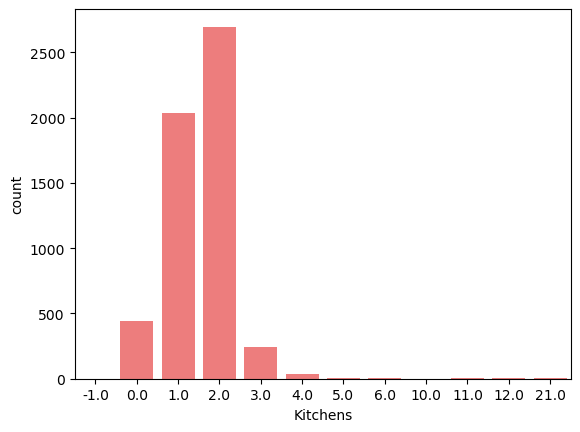

In [149]:
sns.barplot(df['Kitchens'].value_counts());

- Kitchen no. exceeding 4 can be potential outliers

In [151]:
df['Kitchens'].value_counts()

Kitchens
 2.0     2697
 1.0     2033
 0.0      442
 3.0      240
 4.0       33
 5.0        7
 11.0       3
 21.0       3
 6.0        2
 12.0       2
-1.0        1
 10.0       1
Name: count, dtype: int64

In [155]:
df[df['Kitchens']==4][['Description','Area(Marla)','Kitchens','Floor','Storey Unit']]

,Description,Area(Marla),Kitchens,Floor,Storey Unit
146,Brand New 10 Marla Ultra Luxurious Designer Ho...,10.0,4.0,3.0,2.0
237,G-13 Brand New 500 Yds Architect Design Owner ...,20.0,4.0,3.0,2.0
256,* 10 Marla Brand New Proper Corner Double Stor...,10.0,4.0,1.0,2.0
630,F7/3 Luxury Spacious Brand New House Available...,24.0,4.0,3.0,3.0
658,G-13/4 70 FT ROAD Brand New 500 Yds Architect ...,20.0,4.0,2.0,2.0
1187,Studio Apartment For Sale on Installments. In ...,2.9,4.0,1.0,NaN
1259,A Block Gulberg Greens Islamabad Furnished Non...,100.0,4.0,3.0,NaN
1440,cornor polt Extera lend Unable to find investm...,13.0,4.0,NaN,NaN
1529,2-Kanal Bungalow for Sale Naval Anchorage Isla...,40.0,4.0,1.0,NaN
1634,Furnished farm house available for sale A bloc...,100.0,4.0,3.0,NaN


In [154]:
df['Description'].loc[237]

'G-13 Brand New 500 Yds Architect Design Owner Build Double Story House Prime Location Complete Imported Fitting And Fixtures Elite CLASS Construction House 6 Master Bedrooms Attached Stylish Bathrooms Two Drawing Dining Two TV Lounge Two American Style Huge Kitchen With Dirty Kitchen , Store Two Servant Quarter HUGE LUSH GREEN LAWN Huge Car Parking Spaces Reasonable Price Contact Only Serious Buyers Negotiable Price Contact Al Hafiz Estate F-11 ISLAMABAD'

In [94]:
df[df['Kitchens']>4][['Kitchens','Floor','Storey Unit']]

,Kitchens,Floor,Storey Unit
97,5.0,1.0,NaN
128,5.0,2.0,2.0
591,5.0,3.0,2.0
686,5.0,2.0,NaN
1206,22.0,2.0,NaN
1954,11.0,NaN,NaN
2794,5.0,3.0,3.0
2865,6.0,3.0,NaN


### Observations 
- There are many errors in the values. (Need to fix them).

## Store Rooms

<Axes: xlabel='Store Rooms', ylabel='count'>

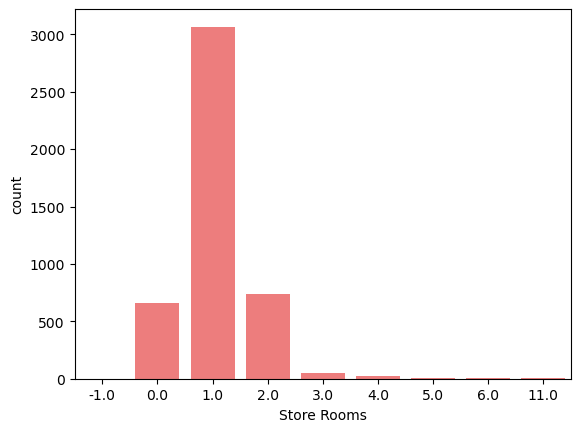

In [156]:
sns.barplot(df['Store Rooms'].value_counts())

In [157]:
df[df['Store Rooms']==0]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
19,Gulberg Greens,Gulberg Greens,Flat,1.15,1.0,2.4,1.0,ghousing societies in Rawalpindi and Islamabad...,"Built in year: 2022, Parking Spaces, Lobby in ...","Bedrooms: 1, Bathrooms: 1, Drawing Room, Dinin...",...,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
23,Unknown,D-12,House,4.25,4.0,4.0,4.0,CDA sector D-12/3(25*40)=4-marla 4-bed room do...,"Built in year: 2019, Parking Spaces: 2, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,2.0
24,Unknown,E-7,House,75.00,7.0,32.0,6.0,Chohan HAY Estate Offers: - E-7 Brand New Hous...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 6, Bathrooms: 7, Servant Quarters, D...",...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
26,Unknown,Naval Anchorage,House,6.90,6.0,14.0,8.0,Naval Anchorage is full of real estate investm...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters, D...",...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
48,Unknown,I-14,House,2.50,6.0,6.0,4.0,Brand New 6 Marla House for Sale Near Sector I...,"Built in year: 2025, Parking Spaces, Flooring,...","Bedrooms: 4, Bathrooms: 6, Servant Quarters, D...",...,0.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6445,Unknown,Taramrri,House,0.98,3.0,5.0,2.0,Tahir Khan Property House For Sale Demand 98 l...,"Built in year: 2015, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
6455,Unknown,Bhara kahu,House,3.40,7.0,10.0,6.0,Near By all Facilities Located on cornal amanu...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...",...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
6476,Askari Heights 4,DHA Phase 5,Flat,3.00,3.0,10.0,3.0,3 Bed Flat For Sale In Askari Heights 4 Reason...,"Built in year, Parking Spaces, Lobby in Buildi...","Bedrooms, Bathrooms, Servant Quarters, Drawing...",...,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
6477,Askari Heights 4,DHA Phase 5,Flat,2.85,3.0,10.0,3.0,A prime location like Askari Heights 4 is the ...,"Built in year, Parking Spaces, Lobby in Buildi...","Bedrooms, Bathrooms, Servant Quarters, Drawing...",...,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


# Saving

In [158]:
df.to_csv('zameen_eda_cleaned.csv')